<div align="center">

# <span style="color: #3498db;">CA5 - Clustering</span>

**<span style="color:rgb(247, 169, 0);">Amirhosein Sabahi</span> - <span style="color:rgb(143, 95, 195);">810101556</span>**

</div>

## Imports

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, homogeneity_score
from sklearn.decomposition import PCA


## Preprocessing

In [2]:
DATA_PATH = r"F:\Term7\AI\amazon_reviews.csv"

SEED = 42
np.random.seed(SEED)

REMOVE_PROXY = True
USE_SUMMARY_PLUS_TEXT = True
SAMPLE_N = 20000
TEXT_COL = "pp_basic"
EMB_PATH = "embeddings_all-MiniLM-L6-v2.npy"

K_RANGE = range(2, 21)
DBSCAN_EPS_GRID = np.round(np.arange(0.10, 0.61, 0.05), 2)
DBSCAN_MIN_SAMPLES_GRID = [3, 5, 10, 20]

HIER_N_RANGE = range(2, 21)
HIER_LINKAGES = ["average", "complete"]

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
TSNE_PERPLEXITY = 30

TRUE_LABEL_COL = None
AUTO_TRUE_LABEL_FALLBACKS = ["Score"]

N_SAMPLES_PER_CLUSTER = 4
MAX_CLUSTERS_TO_PRINT = 30

if REMOVE_PROXY:
    for k in ["HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "http_proxy", "https_proxy", "all_proxy"]:
        os.environ.pop(k, None)

df_raw = pd.read_csv(DATA_PATH)

def parse_raw_entry(s: str) -> dict:
    d = {}
    for line in str(s).splitlines():
        if ": " in line:
            k, v = line.split(": ", 1)
            d[k.strip()] = v.strip()
    return d

if "raw_data" in df_raw.columns:
    df = pd.DataFrame(df_raw["raw_data"].apply(parse_raw_entry).tolist())
else:
    df = df_raw.copy()

keep_cols = ["Id", "UserId", "ProfileName", "HelpfulnessNumerator", "HelpfulnessDenominator", "Score", "Time", "Summary", "Text"]
df = df[[c for c in keep_cols if c in df.columns]].copy()

summary = df.get("Summary", pd.Series([""] * len(df))).fillna("").astype(str)
text = df.get("Text", pd.Series([""] * len(df))).fillna("").astype(str)

if USE_SUMMARY_PLUS_TEXT:
    df["content"] = (summary + " " + text).str.strip()
else:
    df["content"] = text.str.strip()

df = df[df["content"].str.len() >= 20]
df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)

stop_words = set(ENGLISH_STOP_WORDS)

try:
    from nltk.stem import PorterStemmer
    _stemmer = PorterStemmer()
except Exception:
    _stemmer = None

def simple_tokenize(text_: str):
    text_ = str(text_).lower()
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text_)

def preprocess_text(text_: str, remove_stopwords: bool = True, stemming: bool = False, lemmatization: bool = False):
    tokens = simple_tokenize(text_)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]
    if stemming and _stemmer is not None:
        tokens = [_stemmer.stem(t) for t in tokens]
    if lemmatization:
        try:
            from nltk.stem import WordNetLemmatizer
            lemm = WordNetLemmatizer()
            tokens = [lemm.lemmatize(t) for t in tokens]
        except Exception:
            pass
    return " ".join(tokens)

df["pp_basic"] = df["content"].apply(lambda t: preprocess_text(t, remove_stopwords=False, stemming=False))
df["pp_stop"] = df["content"].apply(lambda t: preprocess_text(t, remove_stopwords=True, stemming=False))
df["pp_stop_stem"] = df["content"].apply(lambda t: preprocess_text(t, remove_stopwords=True, stemming=True))
df["pp_stop_lemma"] = df["content"].apply(lambda t: preprocess_text(t, remove_stopwords=True, lemmatization=True))

if TEXT_COL not in df.columns:
    TEXT_COL = "content"

df_work = df[[TEXT_COL, "content"] + ([c for c in ["Score"] if c in df.columns])].dropna(subset=[TEXT_COL]).copy()
df_work = df_work[df_work[TEXT_COL].astype(str).str.len() > 0].reset_index(drop=True)

if SAMPLE_N is not None and len(df_work) > SAMPLE_N:
    df_work = df_work.sample(SAMPLE_N, random_state=SEED).reset_index(drop=True)

texts = df_work[TEXT_COL].astype(str).tolist()

def load_or_make_embeddings(texts_, emb_path):
    if os.path.exists(emb_path):
        emb = np.load(emb_path)
        if isinstance(emb, np.ndarray) and emb.shape[0] == len(texts_):
            return emb
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    emb = model.encode(texts_, batch_size=128, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)
    np.save(emb_path, emb)
    return emb

embeddings = load_or_make_embeddings(texts, EMB_PATH)
X = normalize(embeddings)

## Algorithms

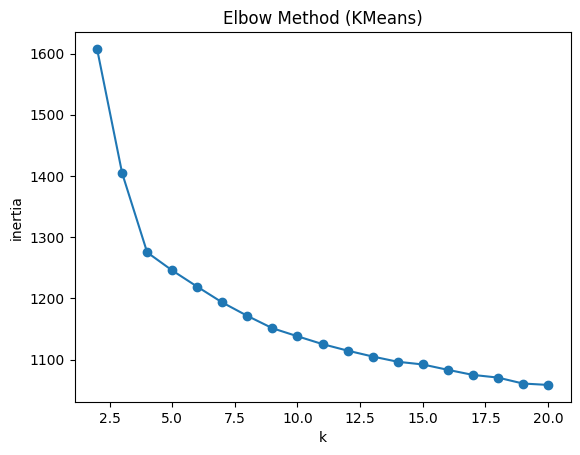

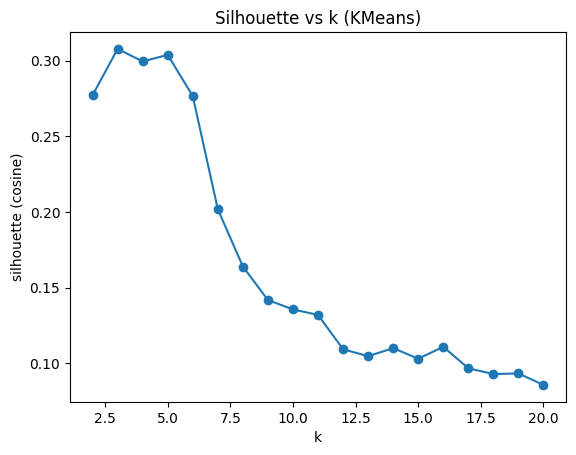

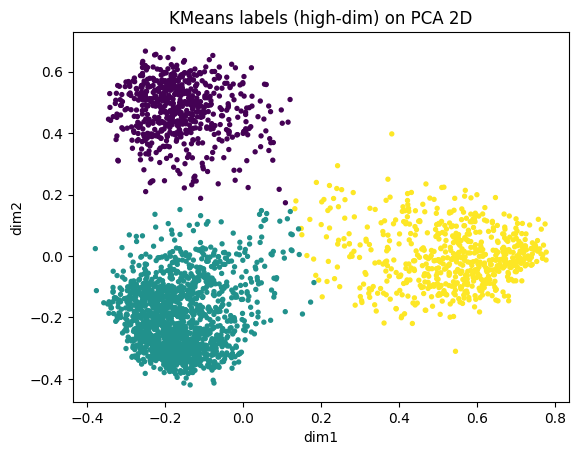

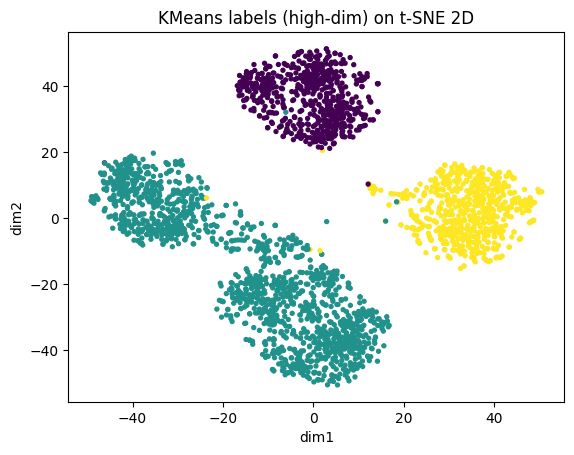

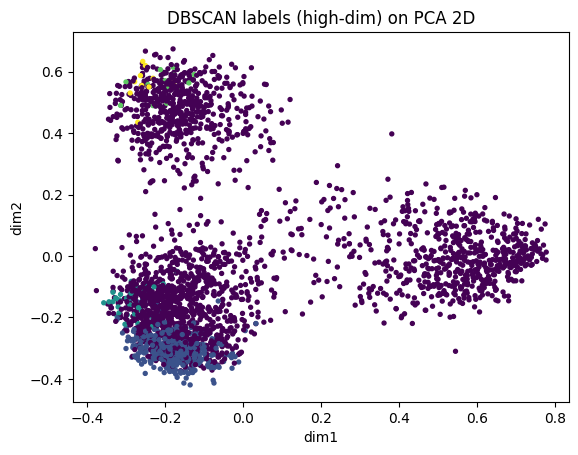

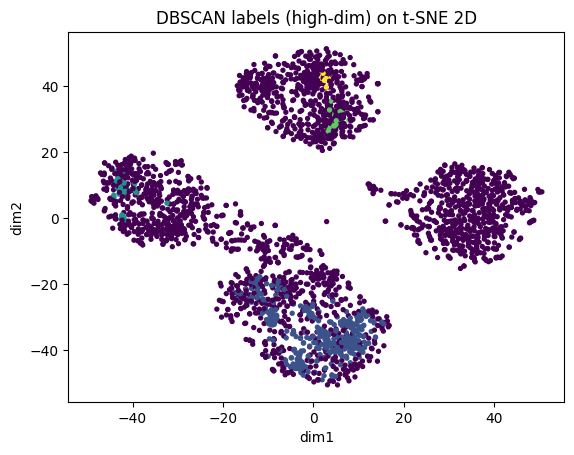

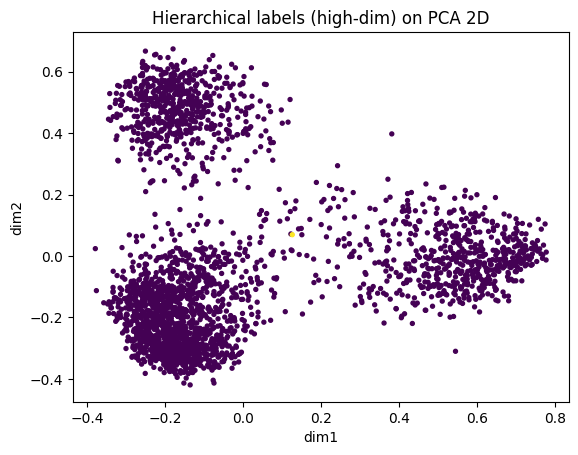

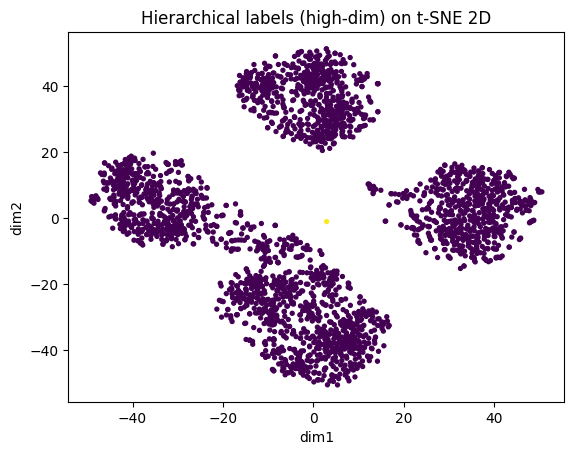

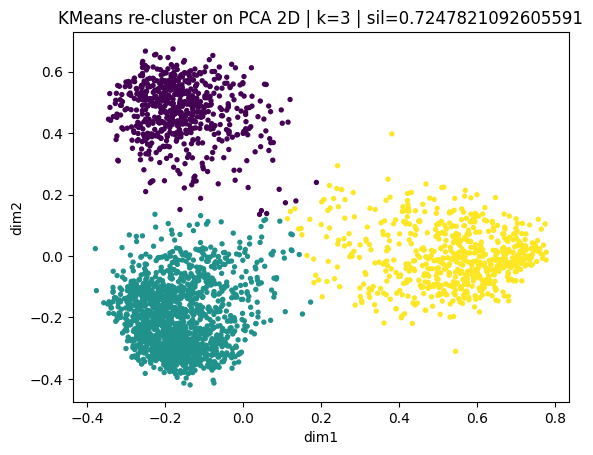

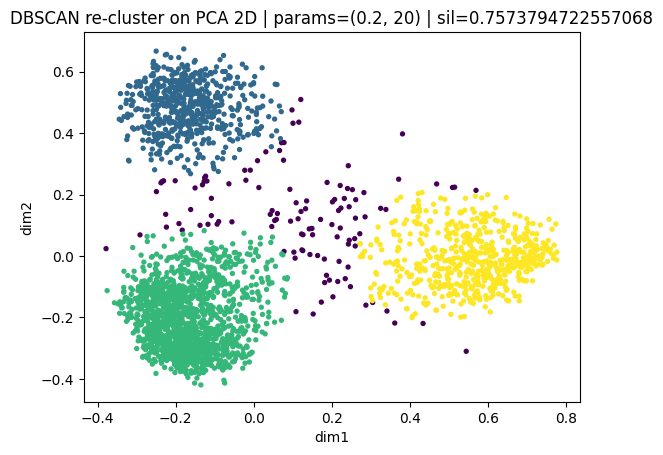

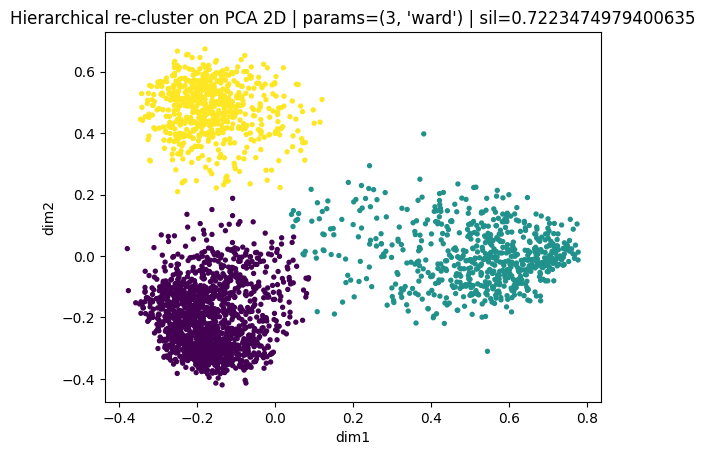

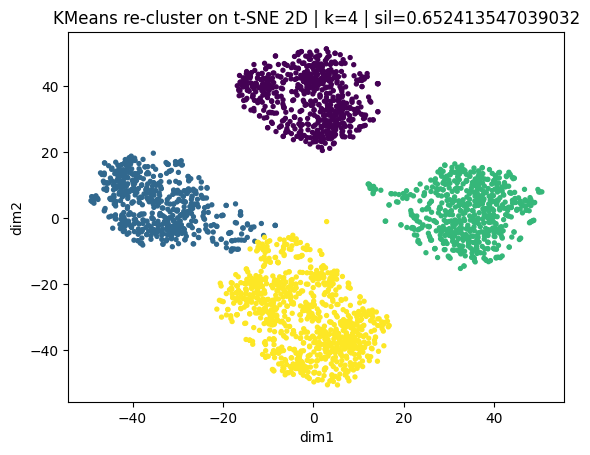

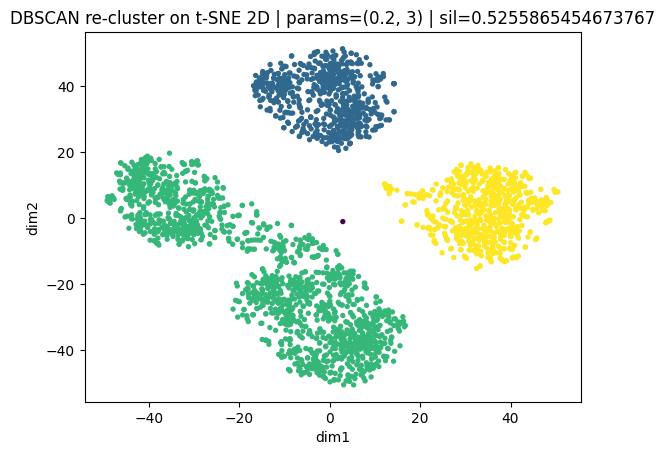

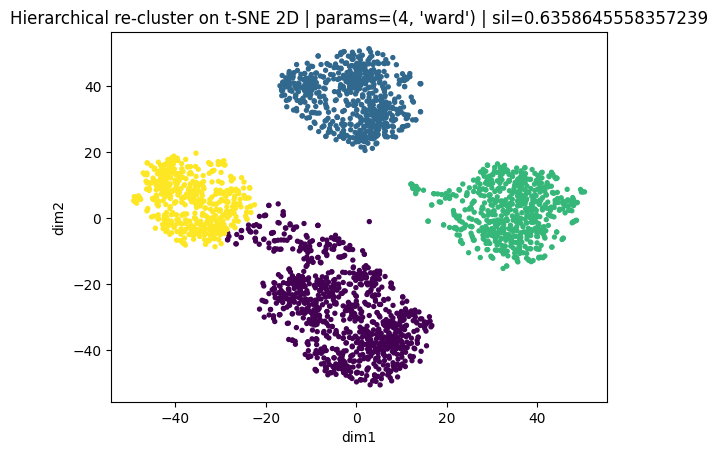

   space       method          label_col  n_clusters  n_noise  silhouette  homogeneity
  PCA_2D       DBSCAN   label_dbscan_pca           3      116    0.757379     0.020706
  PCA_2D Hierarchical     label_hier_pca           3        0    0.722347     0.016816
  PCA_2D       KMeans   label_kmeans_pca           3        0    0.724782     0.017777
high_dim       DBSCAN       label_dbscan           4     2288    0.504140     0.025301
high_dim Hierarchical         label_hier           2        0    0.278568     0.000132
high_dim       KMeans       label_kmeans           3        0    0.307716     0.018477
t-SNE_2D       DBSCAN label_dbscan_other           3        1    0.525587     0.019588
t-SNE_2D Hierarchical   label_hier_other           4        0    0.635865     0.030464
t-SNE_2D       KMeans label_kmeans_other           4        0    0.652414     0.032609
Homogeneity was computed using ground-truth column: Score

Samples for: label_kmeans | clusters=3 | noise=0

--- Cluster 0 (619 it

In [3]:
def safe_silhouette(X_feat, labels, metric="cosine", max_sample=5000):
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.sum() < 10:
        return None
    if len(set(labels[mask])) < 2:
        return None
    sample_size = min(max_sample, int(mask.sum()))
    return float(
        silhouette_score(
            X_feat[mask],
            labels[mask],
            metric=metric,
            sample_size=sample_size,
            random_state=SEED
        )
    )

k_values = list(K_RANGE)
inertias = []
sil_kmeans = []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    s = safe_silhouette(X, labels, metric="cosine")
    sil_kmeans.append(-1 if s is None else s)

plt.figure()
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow Method (KMeans)")
plt.show()

plt.figure()
plt.plot(k_values, sil_kmeans, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette (cosine)")
plt.title("Silhouette vs k (KMeans)")
plt.show()

K_SELECTED = k_values[int(np.argmax(sil_kmeans))]
kmeans = KMeans(n_clusters=K_SELECTED, n_init=10, random_state=SEED)
df_work["label_kmeans"] = kmeans.fit_predict(X)
s_org_km = safe_silhouette(X, df_work["label_kmeans"].values, metric="cosine")

best_db_score = -1
best_db = None
best_db_labels = None

for eps in DBSCAN_EPS_GRID:
    for ms in DBSCAN_MIN_SAMPLES_GRID:
        try:
            db = DBSCAN(eps=float(eps), min_samples=int(ms), metric="cosine", n_jobs=-1)
        except TypeError:
            db = DBSCAN(eps=float(eps), min_samples=int(ms), metric="cosine")
        labels = db.fit_predict(X)
        s = safe_silhouette(X, labels, metric="cosine")
        if s is not None and s > best_db_score:
            best_db_score = s
            best_db = (float(eps), int(ms))
            best_db_labels = labels

if best_db_labels is None:
    best_db = (0.3, 10)
    try:
        best_db_labels = DBSCAN(eps=best_db[0], min_samples=best_db[1], metric="cosine", n_jobs=-1).fit_predict(X)
    except TypeError:
        best_db_labels = DBSCAN(eps=best_db[0], min_samples=best_db[1], metric="cosine").fit_predict(X)

df_work["label_dbscan"] = best_db_labels
s_org_db = safe_silhouette(X, df_work["label_dbscan"].values, metric="cosine")

best_ag_score = -1
best_ag = None
best_ag_labels = None

for n in HIER_N_RANGE:
    for lk in HIER_LINKAGES:
        try:
            ag = AgglomerativeClustering(n_clusters=int(n), linkage=str(lk), metric="cosine")
        except TypeError:
            ag = AgglomerativeClustering(n_clusters=int(n), linkage=str(lk), affinity="cosine")
        labels = ag.fit_predict(X)
        s = safe_silhouette(X, labels, metric="cosine")
        if s is not None and s > best_ag_score:
            best_ag_score = s
            best_ag = (int(n), str(lk))
            best_ag_labels = labels

df_work["label_hier"] = best_ag_labels
s_org_hi = safe_silhouette(X, df_work["label_hier"].values, metric="cosine")

pca2 = PCA(n_components=2, random_state=SEED)
X_pca2 = pca2.fit_transform(X)
X_pca2s = StandardScaler().fit_transform(X_pca2)

try:
    import umap
    reducer_name = "UMAP"
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric="cosine",
        random_state=SEED
    )
    X_other2 = reducer.fit_transform(X)
except Exception:
    from sklearn.manifold import TSNE
    reducer_name = "t-SNE"
    X_other2 = TSNE(
        n_components=2,
        perplexity=TSNE_PERPLEXITY,
        init="pca",
        learning_rate="auto",
        random_state=SEED
    ).fit_transform(X)

X_other2s = StandardScaler().fit_transform(X_other2)

def plot_2d(X2, labels, title):
    plt.figure()
    plt.scatter(X2[:, 0], X2[:, 1], c=np.asarray(labels), s=8)
    plt.title(title)
    plt.xlabel("dim1")
    plt.ylabel("dim2")
    plt.show()

for col, name in [("label_kmeans", "KMeans"), ("label_dbscan", "DBSCAN"), ("label_hier", "Hierarchical")]:
    plot_2d(X_pca2, df_work[col].values, f"{name} labels (high-dim) on PCA 2D")
    plot_2d(X_other2, df_work[col].values, f"{name} labels (high-dim) on {reducer_name} 2D")

def safe_silhouette_euclid(X_feat, labels, max_sample=2000):
    labels = np.asarray(labels)
    mask = labels != -1
    if mask.sum() < 10:
        return None
    if len(set(labels[mask])) < 2:
        return None
    sample_size = min(max_sample, int(mask.sum()))
    return float(
        silhouette_score(
            X_feat[mask],
            labels[mask],
            metric="euclidean",
            sample_size=sample_size,
            random_state=SEED
        )
    )

def best_kmeans_2d(X2, k_min=2, k_max=20):
    ks = list(range(k_min, k_max + 1))
    sils = []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        labels = km.fit_predict(X2)
        s = safe_silhouette_euclid(X2, labels)
        sils.append(-1 if s is None else s)
    k_best = ks[int(np.argmax(sils))]
    km = KMeans(n_clusters=k_best, n_init=10, random_state=SEED)
    labels = km.fit_predict(X2)
    return k_best, labels, float(max(sils))

def best_dbscan_2d(X2, eps_grid=None, min_samples_grid=None):
    if eps_grid is None:
        eps_grid = np.round(np.linspace(0.2, 2.0, 10), 2)
    if min_samples_grid is None:
        min_samples_grid = [3, 5, 10, 20]
    best = None
    best_s = -1
    best_labels = None
    for eps in eps_grid:
        for ms in min_samples_grid:
            try:
                db = DBSCAN(eps=float(eps), min_samples=int(ms), metric="euclidean", n_jobs=-1)
            except TypeError:
                db = DBSCAN(eps=float(eps), min_samples=int(ms), metric="euclidean")
            labels = db.fit_predict(X2)
            s = safe_silhouette_euclid(X2, labels)
            if s is not None and s > best_s:
                best_s = s
                best = (float(eps), int(ms))
                best_labels = labels
    return best, best_labels, (None if best_s < 0 else float(best_s))

def best_hier_2d(X2, n_min=2, n_max=20, linkages=("ward", "complete", "average")):
    best = None
    best_s = -1
    best_labels = None
    for n in range(n_min, n_max + 1):
        for lk in linkages:
            try:
                if lk == "ward":
                    ag = AgglomerativeClustering(n_clusters=n, linkage="ward")
                else:
                    try:
                        ag = AgglomerativeClustering(n_clusters=n, linkage=lk, metric="euclidean")
                    except TypeError:
                        ag = AgglomerativeClustering(n_clusters=n, linkage=lk, affinity="euclidean")
                labels = ag.fit_predict(X2)
            except Exception:
                continue
            s = safe_silhouette_euclid(X2, labels)
            if s is not None and s > best_s:
                best_s = s
                best = (int(n), str(lk))
                best_labels = labels
    return best, best_labels, (None if best_s < 0 else float(best_s))

k_pca, lab_km_pca, s_km_pca = best_kmeans_2d(X_pca2s, 2, 20)
best_db_pca, lab_db_pca, s_db_pca = best_dbscan_2d(X_pca2s)
best_hi_pca, lab_hi_pca, s_hi_pca = best_hier_2d(X_pca2s, 2, 20)

df_work["label_kmeans_pca"] = lab_km_pca
df_work["label_dbscan_pca"] = lab_db_pca
df_work["label_hier_pca"] = lab_hi_pca

plot_2d(X_pca2, df_work["label_kmeans_pca"].values, f"KMeans re-cluster on PCA 2D | k={k_pca} | sil={s_km_pca}")
plot_2d(X_pca2, df_work["label_dbscan_pca"].values, f"DBSCAN re-cluster on PCA 2D | params={best_db_pca} | sil={s_db_pca}")
plot_2d(X_pca2, df_work["label_hier_pca"].values, f"Hierarchical re-cluster on PCA 2D | params={best_hi_pca} | sil={s_hi_pca}")

k_ot, lab_km_ot, s_km_ot = best_kmeans_2d(X_other2s, 2, 20)
best_db_ot, lab_db_ot, s_db_ot = best_dbscan_2d(X_other2s)
best_hi_ot, lab_hi_ot, s_hi_ot = best_hier_2d(X_other2s, 2, 20)

df_work["label_kmeans_other"] = lab_km_ot
df_work["label_dbscan_other"] = lab_db_ot
df_work["label_hier_other"] = lab_hi_ot

plot_2d(X_other2, df_work["label_kmeans_other"].values, f"KMeans re-cluster on {reducer_name} 2D | k={k_ot} | sil={s_km_ot}")
plot_2d(X_other2, df_work["label_dbscan_other"].values, f"DBSCAN re-cluster on {reducer_name} 2D | params={best_db_ot} | sil={s_db_ot}")
plot_2d(X_other2, df_work["label_hier_other"].values, f"Hierarchical re-cluster on {reducer_name} 2D | params={best_hi_ot} | sil={s_hi_ot}")

if TRUE_LABEL_COL is None:
    for c in AUTO_TRUE_LABEL_FALLBACKS:
        if c in df_work.columns:
            TRUE_LABEL_COL = c
            break

y_true = df_work[TRUE_LABEL_COL].values if TRUE_LABEL_COL is not None else None

def try_homogeneity(true_labels, pred_labels):
    if true_labels is None:
        return None
    true_labels = np.asarray(true_labels)
    pred_labels = np.asarray(pred_labels)
    mask = pred_labels != -1
    if mask.sum() < 10:
        return None
    return float(homogeneity_score(true_labels[mask], pred_labels[mask]))

eval_rows = []

def evaluate_one(method_name, label_col, space_name, X_feat, metric):
    labels = df_work[label_col].values
    sil = safe_silhouette(X_feat, labels, metric="cosine", max_sample=5000) if metric == "cosine" else safe_silhouette_euclid(X_feat, labels, max_sample=2000)
    hom = try_homogeneity(y_true, labels)
    n_noise = int((labels == -1).sum())
    n_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)
    eval_rows.append({
        "space": space_name,
        "method": method_name,
        "label_col": label_col,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "silhouette": sil,
        "homogeneity": hom
    })

evaluate_one("KMeans", "label_kmeans", "high_dim", X, "cosine")
evaluate_one("DBSCAN", "label_dbscan", "high_dim", X, "cosine")
evaluate_one("Hierarchical", "label_hier", "high_dim", X, "cosine")

evaluate_one("KMeans", "label_kmeans_pca", "PCA_2D", X_pca2s, "euclidean")
evaluate_one("DBSCAN", "label_dbscan_pca", "PCA_2D", X_pca2s, "euclidean")
evaluate_one("Hierarchical", "label_hier_pca", "PCA_2D", X_pca2s, "euclidean")

evaluate_one("KMeans", "label_kmeans_other", f"{reducer_name}_2D", X_other2s, "euclidean")
evaluate_one("DBSCAN", "label_dbscan_other", f"{reducer_name}_2D", X_other2s, "euclidean")
evaluate_one("Hierarchical", "label_hier_other", f"{reducer_name}_2D", X_other2s, "euclidean")

eval_df = pd.DataFrame(eval_rows)
print(eval_df.sort_values(["space", "method"]).to_string(index=False))

if y_true is None:
    print("Homogeneity was not computed because no ground-truth labels were found in the dataset.")
else:
    print(f"Homogeneity was computed using ground-truth column: {TRUE_LABEL_COL}")

def print_cluster_samples(df_show, label_col, text_col="content", n_per_cluster=4, max_clusters=30):
    labels = df_show[label_col].values
    uniq = sorted([x for x in set(labels) if x != -1])
    uniq = uniq[:max_clusters]
    print("\n" + "=" * 80)
    print(f"Samples for: {label_col} | clusters={len(uniq)} | noise={(labels == -1).sum()}")
    print("=" * 80)
    for c in uniq:
        rows = df_show[df_show[label_col] == c].head(n_per_cluster)
        print(f"\n--- Cluster {c} ({len(df_show[df_show[label_col] == c])} items) ---")
        for i, t in enumerate(rows[text_col].tolist(), 1):
            t = str(t).replace("\n", " ")
            print(f"{i}) {t[:350]}")

label_cols_to_print = [
    "label_kmeans", "label_dbscan", "label_hier",
    "label_kmeans_pca", "label_dbscan_pca", "label_hier_pca",
    "label_kmeans_other", "label_dbscan_other", "label_hier_other"
]

for col in label_cols_to_print:
    if col in df_work.columns:
        print_cluster_samples(df_work, col, text_col="content", n_per_cluster=N_SAMPLES_PER_CLUSTER, max_clusters=MAX_CLUSTERS_TO_PRINT)

high_dim_only = eval_df[eval_df["space"] == "high_dim"].copy()
if not high_dim_only.empty:
    high_dim_only = high_dim_only.sort_values("silhouette", ascending=False)
    best = high_dim_only.iloc[0]
    print("\n" + "=" * 80)
    print("Best method on high_dim (by silhouette):")
    print(best.to_string())
    print("=" * 80)

print("KMeans (high-dim) selected k:", K_SELECTED)
print("DBSCAN best (high-dim):", best_db, "silhouette:", best_db_score)
print("Hierarchical best (high-dim):", best_ag, "silhouette:", best_ag_score)


## Report



## Preprocessing Report

در این بخش متن نظرات کاربران برای آماده‌سازی جهت خوشه‌بندی پیش‌پردازش شد؛ ابتدا فیلدهای غیرمرتبط حذف و متن نظر یا ترکیب خلاصه و متن کامل به‌عنوان ورودی انتخاب گردید، سپس برای کاهش نویز و یکسان‌سازی داده‌ها حروف به حالت یکسان تبدیل شد، علائم نگارشی و کاراکترهای غیرضروری حذف گردید و در چند ترکیب مختلف حذف کلمات توقف نیز اعمال شد و همچنین دو روش ریشه‌یابی Stemming و Lemmatization برای مقایسه بررسی شدند؛ در نهایت برای استخراج ویژگی، متن‌های پردازش‌شده با استفاده از مدل all-MiniLM-L6-v2 در کتابخانه SentenceTransformers به بردارهای عددی با بُعد ثابت تبدیل شدند تا نمایش معنایی فشرده‌ای از هر نظر فراهم شود و امکان محاسبه شباهت و اجرای الگوریتم‌های خوشه‌بندی روی داده‌های عددی مهیا گردد.


## Clustering Report

<div dir="rtl" style="text-align:right;">
در این مرحله ابتدا متن هر نظر به نمایش عددی تبدیل شد تا امکان خوشه‌بندی فراهم شود. برای این کار از کتابخانه SentenceTransformers و مدل all-MiniLM-L6-v2 استفاده گردید و برای هر نمونه، یک بردار ویژگی با بُعد ثابت تولید شد. ورودی بردارسازی می‌توانست متن کامل نظر یا ترکیب Summary و Text باشد تا اطلاعات معنایی بیشتری از محتوای نظر در بردار نهایی منعکس شود.
</div>

<div dir="rtl" style="text-align:right;">
پس از استخراج بردارهای ویژگی، سه الگوریتم خوشه‌بندی K-means، DBSCAN و Hierarchical Clustering روی این بردارها پیاده‌سازی شد. برای K-means تعداد خوشه‌ها باید از قبل تعیین شود، در حالی‌که DBSCAN با تکیه بر چگالی نقاط می‌تواند نویز را نیز شناسایی کند و به K نیاز ندارد. روش سلسله‌مراتبی نیز با ساختار درختی روابط بین داده‌ها را نمایش می‌دهد و امکان تعیین تعداد خوشه‌ها از طریق برش دندروگرام را فراهم می‌کند.
</div>

<div dir="rtl" style="text-align:right;">
پارامترهای هر روش با آزمون و خطا تنظیم شدند و معیار انتخاب پارامترها بر اساس کیفیت جداسازی خوشه‌ها و نتایج ارزیابی انجام شد. در K-means برای تعیین مقدار مناسب K از روش Elbow استفاده گردید و نمودار آن رسم شد تا نقطه‌ای که کاهش خطا کندتر می‌شود به‌عنوان انتخاب مناسب در نظر گرفته شود. برای DBSCAN نیز پارامترهای eps و min_samples در چند مقدار مختلف تست شدند تا تعادل مناسبی بین تعداد خوشه‌ها و میزان نویز ایجاد شود و در خوشه‌بندی سلسله‌مراتبی نیز نوع linkage و تعداد خوشه‌ها بررسی و بهترین تنظیمات انتخاب شد.
</div>



## Dimensionality Reduction Report

<div dir="rtl" style="text-align:right;">
بردارهای استخراج‌شده از مدل‌های زبانی بُعد بالایی دارند و نمایش مستقیم آن‌ها امکان تجسم مناسب را فراهم نمی‌کند؛ بنابراین برای نمایش داده‌ها در فضای دوبعدی یا سه‌بعدی و مشاهده ساختار خوشه‌ها از روش‌های کاهش بُعد استفاده شد. در این پروژه ابتدا PCA به‌عنوان روش خطی کاهش بُعد به کار رفت و سپس یک روش دیگر به دلخواه برای مقایسه انتخاب شد تا الگوی پراکندگی خوشه‌ها بهتر قابل مشاهده باشد. پس از کاهش بُعد با هر دو روش، خوشه‌های حاصل از الگوریتم‌های مختلف روی داده‌های کاهش یافته ترسیم و از نظر میزان جداسازی و هم‌پوشانی بصری با یکدیگر مقایسه شدند. همچنین مطابق صورت مسئله، بعد از کاهش بُعد، الگوریتم‌های خوشه‌بندی دوباره روی داده‌های کم‌بُعد اجرا گردید تا اثر کاهش بُعد بر کیفیت خوشه‌بندی بررسی و نتایج به‌صورت تحلیلی با حالت قبل از کاهش بُعد مقایسه شود.
</div>


<div dir="rtl" style="text-align:right;">
در این بخش نتایج خوشه‌بندی به‌صورت کمی و کیفی ارزیابی شد تا علاوه بر مشاهده ظاهری خوشه‌ها، بتوان کیفیت تفکیک و انسجام آن‌ها را نیز اندازه‌گیری کرد. هدف اصلی این ارزیابی، مقایسه عملکرد الگوریتم‌های مختلف و بررسی اثر انتخاب پارامترها و همچنین کاهش بُعد بر نتیجه نهایی بود. برای این منظور ابتدا معیارهای مناسب معرفی شدند و سپس برای هر الگوریتم مقدار آن‌ها محاسبه و گزارش شد.
</div>

<div dir="rtl" style="text-align:right;">
معیار Silhouette یک معیار داخلی است که بدون نیاز به برچسب واقعی، کیفیت خوشه‌بندی را از نظر فشردگی درون‌خوشه‌ای و جدایی بین خوشه‌ها می‌سنجد. برای هر نمونه، میانگین فاصله آن از نقاط هم‌خوشه به‌عنوان a و کمترین میانگین فاصله آن تا نقاط خوشه‌های دیگر به‌عنوان b در نظر گرفته می‌شود و مقدار Silhouette از رابطه (b−a)/max(a,b) به‌دست می‌آید؛ مقدار نزدیک به ۱ نشان‌دهنده خوشه‌های جدا و فشرده، مقدار نزدیک به صفر بیانگر هم‌پوشانی و مقادیر منفی نشان‌دهنده تخصیص نامناسب است.
</div>

<div dir="rtl" style="text-align:right;">
معیار Homogeneity یک معیار خارجی است و برای محاسبه آن به برچسب واقعی (Ground Truth) نیاز است؛ این معیار بررسی می‌کند که آیا هر خوشه عمدتاً شامل نمونه‌های یک کلاس واقعی است یا خیر. در صورتی که برچسب واقعی در داده وجود نداشته باشد، استفاده از Homogeneity معنی‌دار نیست و باید دلیل آن ذکر شود؛ در این پروژه در صورت نبود برچسب مرجع، تمرکز اصلی بر Silhouette و تحلیل کیفی محتوای خوشه‌ها قرار گرفت و Homogeneity صرفاً در حالتی محاسبه شد که ستون برچسب قابل اتکا در داده موجود باشد.
</div>

<div dir="rtl" style="text-align:right;">
پس از اجرای هر الگوریتم خوشه‌بندی، مقادیر معیارها محاسبه و همراه با نمودارهای خوشه‌بندی گزارش شدند تا هم ارزیابی عددی و هم مقایسه بصری انجام شود. همچنین نتایج قبل از کاهش بُعد با نتایج پس از کاهش بُعد مقایسه گردید تا مشخص شود کاهش بُعد چه اثری بر ساختار خوشه‌ها و کیفیت جداسازی دارد؛ علاوه بر نمایش خوشه‌ها روی فضای دوبعدی یا سه‌بعدی، الگوریتم‌ها دوباره روی داده‌های کم‌بُعد اجرا شدند تا اختلاف عملکرد به‌صورت مستقیم قابل تحلیل باشد.
</div>

<div dir="rtl" style="text-align:right;">
برای ارزیابی کیفی، از هر خوشه حداقل چهار نمونه چاپ و از نظر شباهت معنایی و موضوعی بررسی شد تا مشخص شود خوشه‌ها واقعاً بیانگر یک موضوع یا الگوی مشترک هستند یا صرفاً به دلیل نزدیکی عددی تشکیل شده‌اند. در نهایت با ترکیب نتایج کمی (مانند Silhouette و در صورت امکان Homogeneity)، میزان نویز و پراکندگی خوشه‌ها، و تحلیل محتوایی نمونه‌ها، بهترین روش خوشه‌بندی انتخاب شد و دلایل برتری آن شامل کیفیت جداسازی، پایداری نسبت به پارامترها، و معناداری موضوعی خوشه‌ها به‌صورت مستند ارائه گردید.
</div>


## Questions


## Preprocessing Questions

1. بهترین کارایی معمولاً با ریشه‌یابی معنایی (Lemmatization) به دست می‌آید زیرا شکل اصلی کلمه را حفظ می‌کند.

ترکیب این روش با حذف کلمات بی‌اهمیت (Stop Words) و نرمال‌سازی، درک مدل از محتوا را افزایش می‌دهد.

استفاده از بازنمایی‌های معنایی پیشرفته (مانند بردارها) اغلب از روش‌های مبتنی بر شمارش ساده بهتر عمل می‌کند.



2. پیش‌پردازش به منظور کاهش نویز و یکسان‌سازی ورودی‌های متنی انجام می‌گیرد.

این کار باعث می‌شود تا الگوریتم خوشه‌بندی بر روی مفاهیم اصلی تمرکز کند نه بر روی تفاوت‌های ظاهری کلمات.

بدون این کار، حجم زیاد داده‌های غیرضروری باعث کاهش دقت و کارایی مدل می‌شود.



3. ریشه‌یابی خام (Stemming) کلمات را به ریشه‌های سریع و تقریبی تبدیل می‌کند که می‌تواند منجر به کلمات بی‌معنی شود.

ریشه‌یابی معنایی (Lemmatization) کلمه را به شکل پایه دستوری صحیح آن می‌برد و دقیق‌تر است.

عیب Lemmatization کندی آن نسبت به Stemming است، اما مزیت آن کیفیت بالاتر ویژگی‌ها است.





4. الگوریتم‌های خوشه‌بندی مانند میانگین‌گیری برای کار به ورودی‌های عددی نیاز دارند.

تبدیل متن به بردارهای عددی (استخراج ویژگی) تنها راهی است که محتوای متنی در یک فضای ریاضی قابل نمایش باشد.

استفاده مستقیم از رشته‌های متنی خام، امکان محاسبه‌ی فاصله و شباهت مورد نیاز برای خوشه‌بندی را از بین می‌برد.


## Clustering Questions

1. یادگیری با ناظر از داده‌هایی استفاده می‌کند که دارای برچسب صحیح یا پاسخ درست هستند تا مدل را آموزش دهد.

یادگیری بدون ناظر بر روی داده‌های بدون برچسب عمل کرده و به دنبال کشف ساختارهای پنهان و الگوها در داده‌ها است.

تفاوت اصلی در وجود یا عدم وجود راهنما (برچسب) در مجموعه آموزشی برای هدایت فرآیند یادگیری است.


2. بردارهای ویژگی متون را به فضای عددی پیوسته و با ابعاد کمتر نگاشت می‌کنند که برای محاسبات ریاضی ضروری است.

این بردارها معنای واژگان و روابط دستوری بین کلمات را در خود کدگذاری می‌کنند.

ویژگی‌های مهم آن‌ها شامل چگالی معنایی بالا و توانایی درک شباهت‌های مفهومی بین جملات است.

3. روش کیسه کلمات فقط تعداد تکرار کلمات را ثبت می‌کند و کاملاً فاقد ترتیب و مفهوم است.

روش تراکم فراوانی-معکوس اسناد (TF-IDF) اهمیت کلمات در یک سند نسبت به کل مجموعه را نشان می‌دهد اما همچنان مفهوم کلی جمله را از دست می‌دهد.

بردارهای کلمه/جمله (مانند مدل‌های ترانسفورمر) بالاترین کیفیت معنایی را دارند زیرا زمینه و رابطه بین کلمات را در نظر می‌گیرند.

4. مدل‌های ترانسفورمر جمله ساختارهایی هستند که برای تولید یک بردار واحد برای کل جمله طراحی شده‌اند.

مدل “all-MiniLM-L6-v2” یک نسخه بسیار کارآمد و سبک از این مدل‌ها است که سرعت بالا و مصرف منابع کمتری دارد.

این مدل‌ها برای کارهایی مانند خوشه‌بندی و بازیابی اطلاعات که نیاز به مقایسه سریع شباهت جملات دارند، بهینه‌سازی شده‌اند.

5. این روش با رسم نمودار مجموع مربعات خطا (SSE) در برابر تعداد خوشه‌ها کار می‌کند.

نقطهٔ مناسب برای انتخاب تعداد بهینه، نقطه‌ای است که نمودار از یک شیب تند به یک شیب ملایم و تخت تغییر می‌کند.

این نقطهٔ تغییر شکل، مانند یک آرنج به نظر می‌رسد و نشان‌دهندهٔ بازده کاهشی در افزایش تعداد خوشه‌ها است.

6. میانگین کا (K-Means) هر خوشه را با محاسبه میانگین نقاط در آن خوشه تعریف می‌کند و به دنبال کمینه‌سازی فاصله‌ها است.

خوشه‌بندی مبتنی بر چگالی (DBSCAN) خوشه‌ها را به عنوان نواحی دارای چگالی بالا تعریف می‌کند و نقاط کم‌تراکم را نویز می‌داند.

خوشه‌بندی سلسله‌مراتبی تجمعی (Agglomerative) یک رویکرد از پایین به بالا است که کوچکترین خوشه‌ها را تا رسیدن به یک خوشه نهایی، به هم می‌پیوندد.


## Dimensionality Reduction questions
1. تبدیل مولفه‌های اصلی یک روش خطی برای کاهش ابعاد داده‌های بزرگ است.

این روش بردار‌های جدیدی به نام مولفه‌های اصلی را پیدا می‌کند که بیشترین واریانس داده‌ها را در خود نگهداری می‌کنند.

با انتخاب مولفه‌هایی که بیشترین واریانس را دارند، می‌توانیم داده‌ها را در فضایی با ابعاد کمتر نمایش دهیم.

2. تحلیل مؤلفه‌های اصلی (PCA) یک روش خطی است که بر اساس واریانس داده‌ها عمل کرده و ساختار اصلی را حفظ می‌کند.

تی-اس‌ان‌ای (t-SNE) یک روش غیرخطی است که هدف آن نمایش بهتر خوشه‌ها و ساختارهای محلی در دو یا سه بعد است.

PCA برای فشرده‌سازی کلی مناسب است، در حالی که t-SNE برای تجسم و جداسازی خوشه‌ها به‌ویژه پس از خوشه‌بندی، عملکرد بهتری دارد.